In [ ]:
nltk.download(['stopwords','wordnet','punkt','punkt_tab'])

In [129]:
# Libraries
import pandas as pd
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from nltk.probability import FreqDist
from nltk.tokenize import word_tokenize
import seaborn as sns

In [130]:
#Import Dataset
df= pd.read_csv('Flipkart Reviews.csv')

In [131]:
# Dataset Overview - Shape
df.shape

(2304, 4)

In [132]:
# Dataset Overview - First 5 rows
df.head()

,Unnamed: 0,Product_name,Review,Rating
0,0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5
1,1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5
2,2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5
3,3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5
4,4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5


In [133]:
# Dataset Overview - Data types, Number of non-null entries, and Memory usage.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2304 entries, 0 to 2303
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    2304 non-null   int64 
 1   Product_name  2304 non-null   object
 2   Review        2304 non-null   object
 3   Rating        2304 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 72.1+ KB


In [134]:
# Dataset Overview - Summary Stats
df.describe(include='all')

,Unnamed: 0,Product_name,Review,Rating
count,2304.000000,2304,2304,2304.000000
unique,NaN,231,1358,NaN
top,NaN,"realme C25Y (Glacier Blue, 128 GB) (4 GB RAM)",Good,NaN
freq,NaN,20,47,NaN
mean,1151.500000,NaN,NaN,4.259549
std,665.251832,NaN,NaN,1.180017
min,0.000000,NaN,NaN,1.000000
25%,575.750000,NaN,NaN,4.000000
50%,1151.500000,NaN,NaN,5.000000
75%,1727.250000,NaN,NaN,5.000000


In [135]:
# EDA & Pre-processing
df_cleaned = df.drop(columns=['Unnamed: 0']) # Drop column
df_cleaned.head()

,Product_name,Review,Rating
0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5
1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5
2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5
3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5
4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5


In [136]:
# EDA & Pre-processing - Check missing values
df.isnull()

,Unnamed: 0,Product_name,Review,Rating
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
2299,False,False,False,False
2300,False,False,False,False
2301,False,False,False,False
2302,False,False,False,False


In [137]:
# EDA & Pre-processing
df_cleaned.isnull().sum() # Sum of missing values

Product_name    0
Review          0
Rating          0
dtype: int64

In [138]:
# EDA & Pre-processing
tokenizer = RegexpTokenizer(r'[a-zA-Z0-9\'-]+') # Initialize tokenizer that keeps letters, numbers, apostrophes, and hyphens.
stop_words = set(stopwords.words('english')) # Load the set of English stopwords to remove noise from text
stemmer = PorterStemmer() # Initialize the Porter Stemmer to reduce words to their root form

# Function to clean raw review text
def preprocess_text(text):
    tokenized_document = tokenizer.tokenize(text.lower()) # Tokenize the text
    cleaned_tokens = [word for word in tokenized_document if word not in stop_words] # Remove stopwords
    stemmed_text = [stemmer.stem(word) for word in cleaned_tokens] # Apply stemming
    return ' '.join(stemmed_text)

In [139]:
# Create a new processed text column
df_cleaned['Processed Review'] = df_cleaned['Review'].apply(preprocess_text)
df_cleaned[['Review', 'Processed Review']].head()

,Review,Processed Review
0,Best under 60k Great performanceI got it for a...,best 60k great performancei got around 58500ba...
1,Good perfomence...,good perfom
2,Great performance but usually it has also that...,great perform usual also game laptop' issu bat...
3,My wife is so happy and best product 👌🏻😘,wife happi best product
4,"Light weight laptop with new amazing features,...",light weight laptop new amaz featur batteri li...


In [140]:
# EDA & Pre-processing - Add sentiments and store in a new colmun
def classify_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

df_cleaned['Sentiment'] = df_cleaned['Rating'].apply(classify_sentiment)

print(df_cleaned['Sentiment'].value_counts())

Sentiment
Positive    1934
Negative     230
Neutral      140
Name: count, dtype: int64


In [141]:
# EDA & Pre-processing - Dataset with Sentiment column
df_cleaned.head(10)

,Product_name,Review,Rating,Processed Review,Sentiment
0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5,best 60k great performancei got around 58500ba...,Positive
1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5,good perfom,Positive
2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5,great perform usual also game laptop' issu bat...,Positive
3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5,wife happi best product,Positive
4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5,light weight laptop new amaz featur batteri li...,Positive
5,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Amazing laptop, am so much happy, thanks for F...",5,amaz laptop much happi thank flipkart,Positive
6,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,Over all a good laptop for personal use,5,good laptop person use,Positive
7,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,Thank you so much Flipkart,4,thank much flipkart,Positive
8,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,Amazing product,5,amaz product,Positive
9,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Good for normal work , students, online classe...",3,good normal work student onlin class watch mov...,Neutral


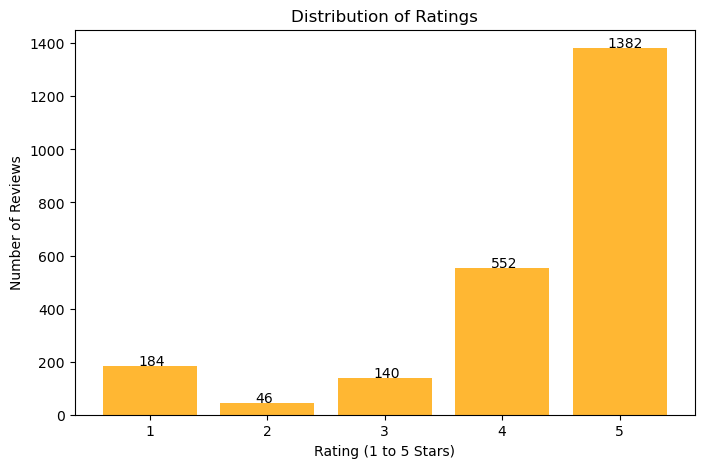

In [142]:
# EDA & Pre-processing - Distributions - Ratings with No. of Reviews
rating_counts = df_cleaned['Rating'].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(rating_counts.index, rating_counts.values, color='orange', alpha=0.8)

plt.title("Distribution of Ratings")
plt.xlabel("Rating (1 to 5 Stars)")
plt.ylabel("Number of Reviews")

for i, v in enumerate(rating_counts.values):
    plt.text(rating_counts.index[i] - 0.1, v + 2, str(v), color='black')

plt.xticks([1,2,3,4,5])
plt.show()

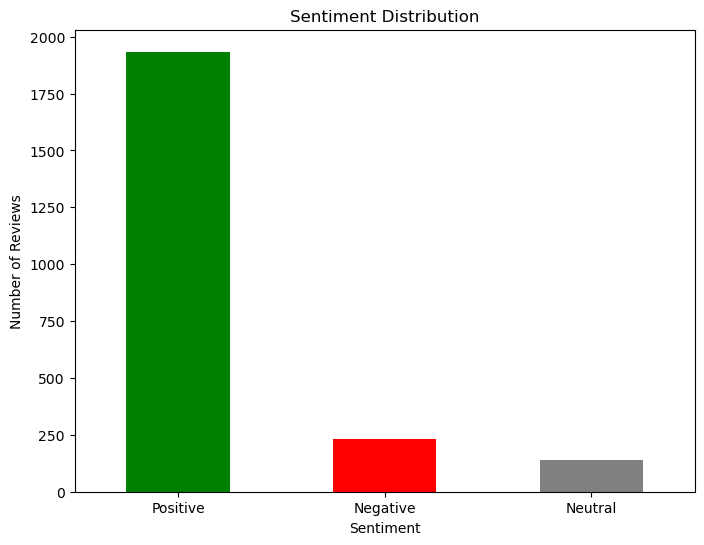

In [143]:
# EDA & Pre-processing - Distributions - Plot the sentiment counts.
sentiment_counts = df_cleaned['Sentiment'].value_counts()

plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color=['green', 'red', 'gray'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

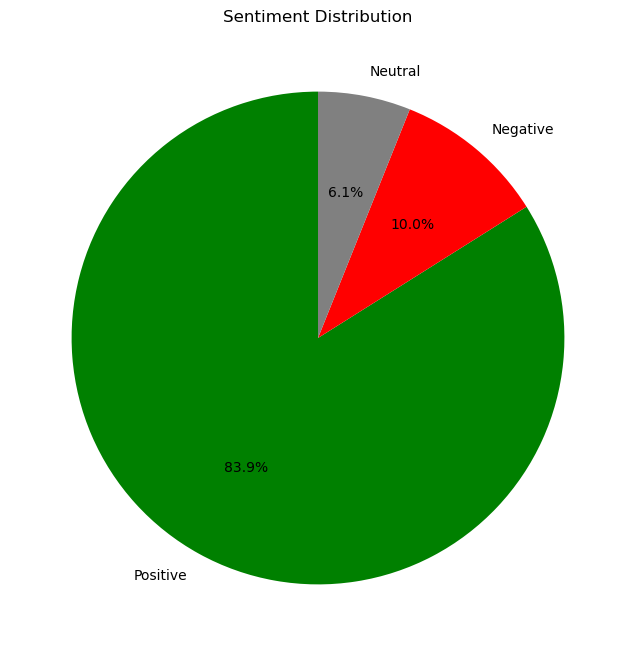

In [144]:
# EDA & Pre-processing - Distributions - Plot the pie chart with percentages
sentiment_counts = df_cleaned['Sentiment'].value_counts()

plt.figure(figsize=(8, 8))

colors = ['green', 'red', 'gray']

sentiment_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.title('Sentiment Distribution')
plt.ylabel('')
plt.show()

In [145]:
# Extract all processed reviews that were classified as Positive & Neagtive
positive_reviews = df_cleaned[df_cleaned['Sentiment'] == 'Positive']['Processed Review'] 
negative_reviews = df_cleaned[df_cleaned['Sentiment'] == 'Negative']['Processed Review']

# Combine all Positive & Negative reviews into a single large string
positive_text = ' '.join(positive_reviews)
negative_text = ' '.join(negative_reviews)

# Tokenize every word in all Positive & Negative reviews
positive_tokens = [word for review in positive_reviews for word in word_tokenize(review)]
negative_tokens = [word for review in negative_reviews for word in word_tokenize(review)]

# Calculate the frequency of words in Positive & Negative reviews
positive_freq = FreqDist(positive_tokens)
negative_freq = FreqDist(negative_tokens)

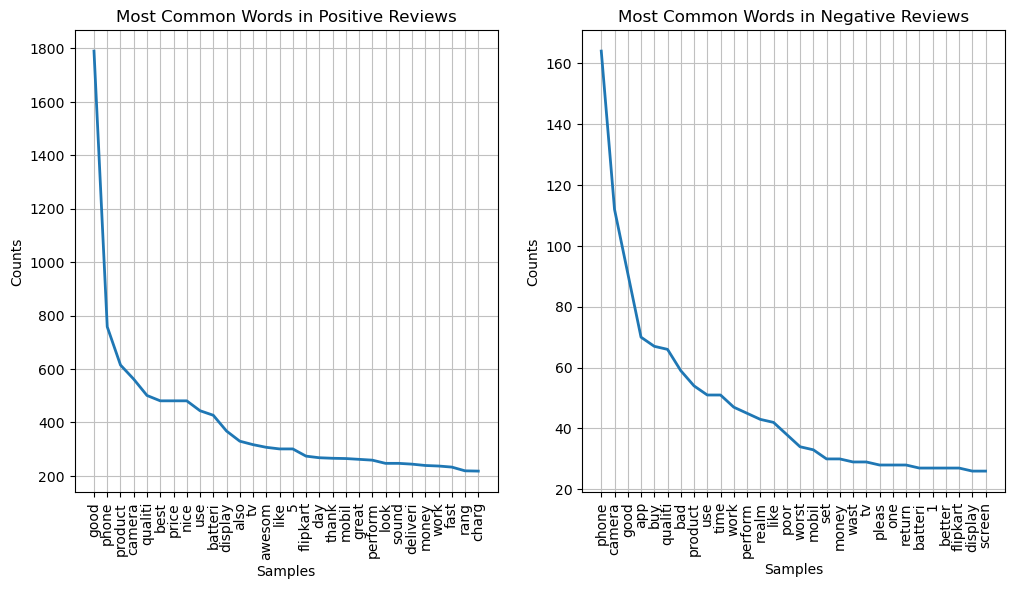

In [146]:
# EDA & Pre-processing - Distributions - Plot most common words in Positive & Negative reviews
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
positive_freq.plot(30, cumulative=False)
plt.title('Most Common Words in Positive Reviews')

plt.subplot(1, 2, 2)
negative_freq.plot(30, cumulative=False)
plt.title('Most Common Words in Negative Reviews')

plt.show()

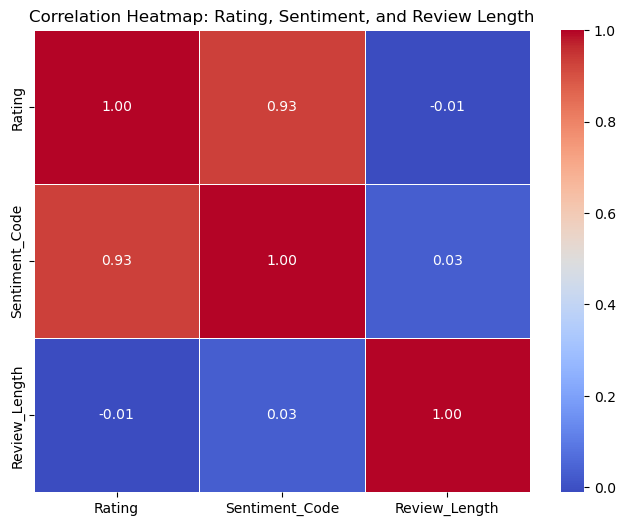

In [147]:
# EDA & Pre-processing
# Create a new column representing the length of each review
df_cleaned['Review_Length'] = df_cleaned['Review'].apply(lambda x: len(x.split()))

# Map categorical sentiment labels to numerical codes for correlation analysis
sentiment_map = {
    'Positive': 2,
    'Neutral': 1,
    'Negative': 0
}

# Create a new numeric column 'Sentiment_Code' based on the mapping above
df_cleaned['Sentiment_Code'] = df_cleaned['Sentiment'].map(sentiment_map)

# Select the numeric features that will be included in the correlation matrix
corr_features = df_cleaned[['Rating', 'Sentiment_Code', 'Review_Length']]

# Compute the correlation matrix to examine relationships among these variables
corr_matrix = corr_features.corr()

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap: Rating, Sentiment, and Review Length")
plt.show()

In [148]:
# Create Bag of Words
vectorizer = CountVectorizer(max_features=5000)

X = vectorizer.fit_transform(df_cleaned['Processed Review'])
y = df_cleaned['Sentiment']

In [149]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [150]:
# Train Naive Bayes Model
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [151]:
# Predictions
y_pred = model.predict(X_test)

In [152]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8980477223427332

Classification Report:
               precision    recall  f1-score   support

    Negative       0.89      0.54      0.68        46
     Neutral       0.73      0.29      0.41        28
    Positive       0.90      0.98      0.94       387

    accuracy                           0.90       461
   macro avg       0.84      0.60      0.68       461
weighted avg       0.89      0.90      0.88       461


Confusion Matrix:
 [[ 25   0  21]
 [  0   8  20]
 [  3   3 381]]


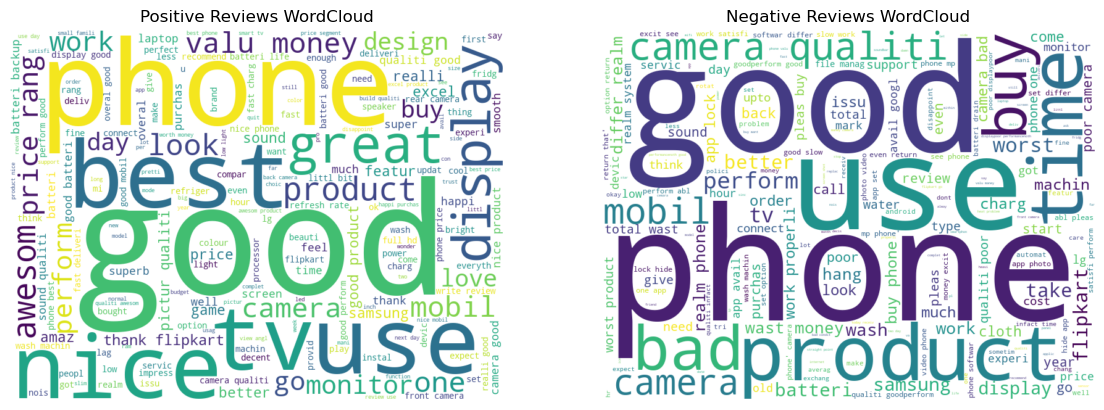

In [153]:
# Word Cloud for Positive & Negative reviews
positive_wordcloud = WordCloud(width=800, height=600, background_color='white').generate(positive_text)
negative_wordcloud = WordCloud(width=800, height=600, background_color='white').generate(negative_text)

plt.figure(figsize=(14, 8))

plt.subplot(1, 2, 1)
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Reviews WordCloud')

plt.subplot(1, 2, 2)
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Reviews WordCloud')

plt.show()

In [118]:
df_cleaned.to_csv('Processed Flipkart Reviews.csv', index=False)